# **SmileSage: Advanced Dental Condition Classification**
## **Overview**
SmileSage is an advanced deep learning system for automated dental condition classification using computer vision. This notebook implements a fine-tuned EfficientNetB0 model to classify seven different dental conditions with high accuracy.
## **Key Features**

- **Multi-class Classification**: Identifies 7 dental conditions (Calculus, Caries, Gingivitis, Healthy, Hypodontia, Tooth discoloration, Ulcers)
- **Transfer Learning**: Utilizes EfficientNetB0 pre-trained on ImageNet for optimal performance
- **Grad-CAM Visualization**: Provides interpretable AI with attention heatmaps
- **Comprehensive Evaluation**: Includes detailed performance metrics and confusion matrices

-----------------

## **1. Environment Setup and Dependencies**
First, let's import all necessary libraries and set up our environment for the dental classification task.

In [1]:
# Import necessary libraries
from google.colab import drive, files
import os
import matplotlib.pyplot as plt
import cv2
import random
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models, callbacks, applications
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.cm as cm
from PIL import Image
from IPython.display import display

In [2]:
# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

Mounting Google Drive...
Mounted at /content/drive
✅ Google Drive mounted successfully!


## **2. Configuration and Constants**
Define all configuration parameters, paths, and constants used throughout the notebook. This centralized approach makes the code more maintainable and easier to modify.

In [3]:
# Dataset configuration
DATASET_PATH = '/content/drive/MyDrive/revised_dental_dataset'
MODEL_SAVE_PATH = '/content/drive/MyDrive/EfficientNetB0_dental_model_finetuned.keras'

# Model configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

# Define class names (CRITICAL FOR CONSISTENCY)
CLASS_NAMES = [
    "Calculus",              # Dental tartar buildup
    "Caries",                # Tooth decay/cavities
    "Gingivitis",            # Gum inflammation
    "Healthy",               # Normal/healthy teeth
    "Hypodontia",            # Missing teeth condition
    "Tooth_discoloration",   # Teeth staining/discoloration
    "Ulcers"                 # Mouth ulcers/sores
]
NUM_CLASSES = len(CLASS_NAMES)

print(f"📊 Dataset: {DATASET_PATH}")
print(f"🎯 Classes: {CLASS_NAMES}")
print(f"📈 Total Classes: {NUM_CLASSES}")


📊 Dataset: /content/drive/MyDrive/revised_dental_dataset
🎯 Classes: ['Calculus', 'Caries', 'Gingivitis', 'Healthy', 'Hypodontia', 'Tooth_discoloration', 'Ulcers']
📈 Total Classes: 7


## **3. Dataset Exploration and Analysis**
Before training, we need to understand our dataset structure, class distribution, and sample images. This exploratory data analysis helps identify potential issues and informs preprocessing decisions.

=== DATASET EXPLORATION ===
✅ Calculus: 1194 images
✅ Caries: 1204 images
✅ Gingivitis: 1202 images
✅ Healthy: 1195 images
✅ Hypodontia: 1197 images
✅ Tooth_discoloration: 1204 images
✅ Ulcers: 1201 images

📊 Class Distribution:
                     Image Count
Calculus                    1194
Caries                      1204
Gingivitis                  1202
Healthy                     1195
Hypodontia                  1197
Tooth_discoloration         1204
Ulcers                      1201


<Figure size 1200x600 with 0 Axes>

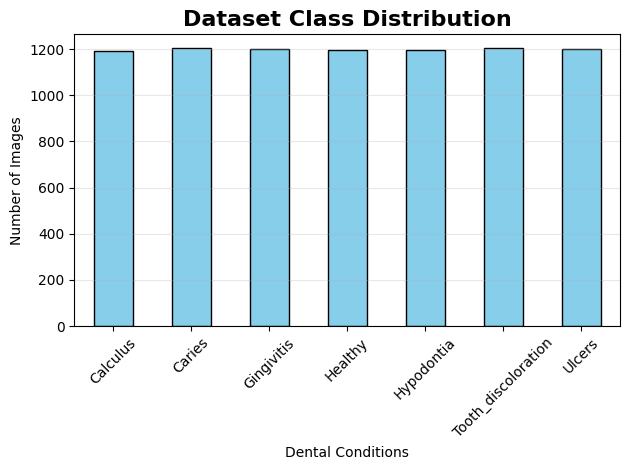


=== SAMPLE IMAGES ===


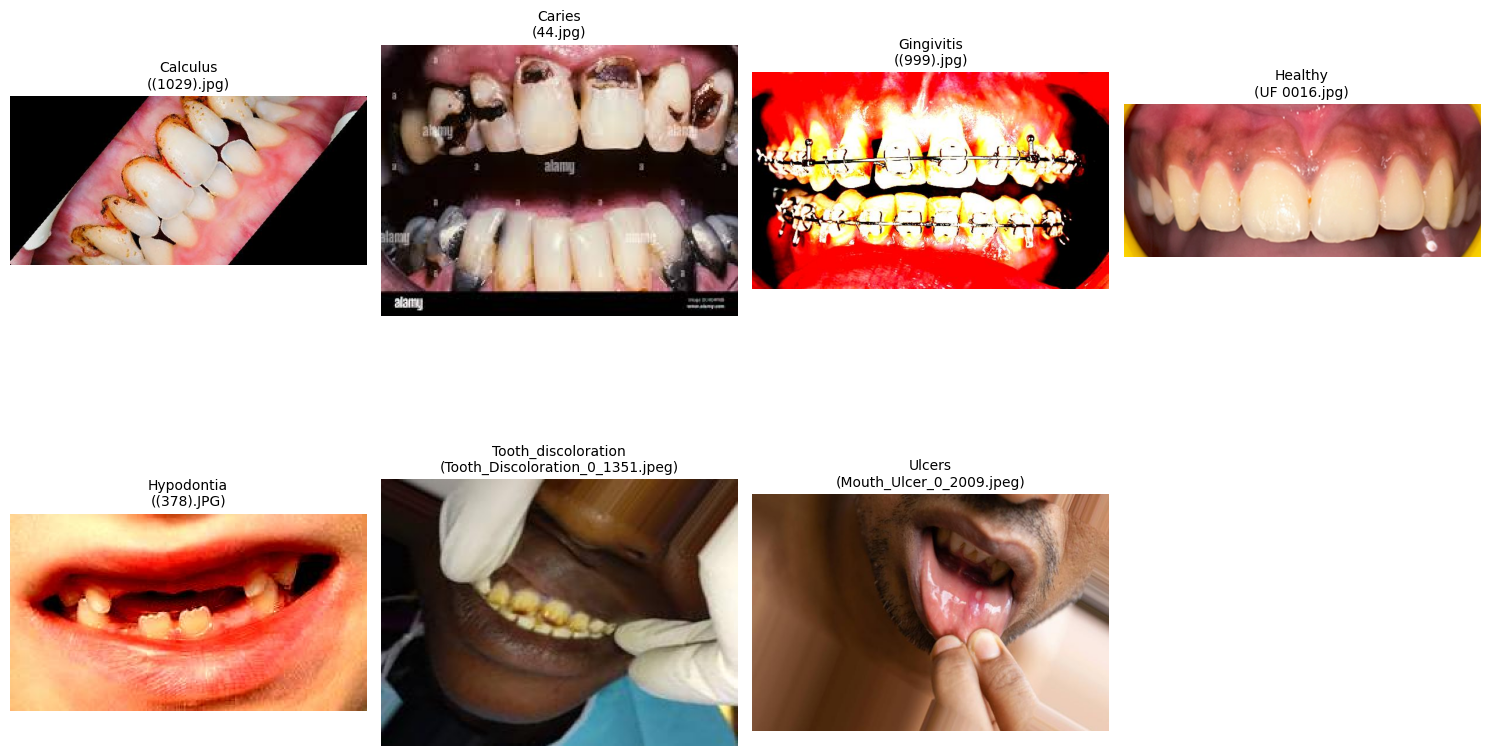

In [4]:
def explore_dataset():
    """
    Comprehensive dataset exploration function.

    Returns:
        dict: Class distribution counts
    """
    print("=== DATASET EXPLORATION ===")

    # Check folder structure
    class_counts = {}
    for folder in CLASS_NAMES:
        folder_path = os.path.join(DATASET_PATH, folder)
        if os.path.exists(folder_path):
            num_images = len(os.listdir(folder_path))
            class_counts[folder] = num_images
            print(f"✅ {folder}: {num_images} images")
        else:
            print(f"❌ Missing folder: {folder}")

    # Create distribution DataFrame
    df = pd.DataFrame.from_dict(class_counts, orient='index', columns=['Image Count'])
    print(f"\n📊 Class Distribution:\n{df}")

    # Plot distribution
    plt.figure(figsize=(12, 6))
    df.plot(kind='bar', legend=False, color='skyblue', edgecolor='black')
    plt.title('Dataset Class Distribution', fontsize=16, fontweight='bold')
    plt.ylabel('Number of Images')
    plt.xlabel('Dental Conditions')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return class_counts

def visualize_samples():
    """Display sample images from each class"""
    print("\n=== SAMPLE IMAGES ===")
    plt.figure(figsize=(15, 10))

    for i, cls in enumerate(CLASS_NAMES):
        folder_path = os.path.join(DATASET_PATH, cls)
        if not os.path.exists(folder_path):
            continue

        # Get random sample
        sample_images = os.listdir(folder_path)
        sample_image = random.choice(sample_images)
        img_path = os.path.join(folder_path, sample_image)

        # Load and display
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(f"{cls}\n({sample_image})", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run exploration
class_counts = explore_dataset()
visualize_samples()

## **4. Data Loading and Preprocessing Pipeline**
Create efficient data loading pipelines with proper preprocessing for training, validation, and testing datasets.

In [7]:
def create_datasets():
    """
    Create train, validation, and test datasets with proper splits.

    Returns:
        tuple: (train_ds, val_ds, test_ds) - TensorFlow datasets
    """
    print("=== CREATING DATASETS ===")

    # Create train/val split
    train_ds = image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.3,
        subset='training',
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_names=CLASS_NAMES
    )

    val_ds = image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.3,
        subset='validation',
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_names=CLASS_NAMES
    )

    # Split validation into val/test
    val_batches = tf.data.experimental.cardinality(val_ds)
    test_ds = val_ds.take(val_batches // 2)
    val_ds = val_ds.skip(val_batches // 2)

    print(f"📦 Train batches: {tf.data.experimental.cardinality(train_ds)}")
    print(f"📦 Validation batches: {tf.data.experimental.cardinality(val_ds)}")
    print(f"📦 Test batches: {tf.data.experimental.cardinality(test_ds)}")

    return train_ds, val_ds, test_ds

def setup_preprocessing():
    """Setup data augmentation and preprocessing"""
    print("=== SETTING UP PREPROCESSING ===")

    # Data augmentation (conservative for medical images)
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
    ], name="data_augmentation")

    # Preprocessing function
    def preprocess(image, label):
        image = preprocess_input(image)
        return image, label

    return data_augmentation, preprocess

def apply_preprocessing(train_ds, val_ds, test_ds, data_augmentation, preprocess_fn):
    """Apply preprocessing to datasets"""
    AUTOTUNE = tf.data.AUTOTUNE

    # Apply to training set (with augmentation)
    train_ds = (
        train_ds
        .map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=AUTOTUNE)
        .map(preprocess_fn, num_parallel_calls=AUTOTUNE)
        .shuffle(1000)
        .cache()
        .prefetch(buffer_size=AUTOTUNE)
    )

    # Apply to validation set (no augmentation)
    val_ds = (
        val_ds
        .map(preprocess_fn, num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(buffer_size=AUTOTUNE)
    )

    # Apply to test set (no augmentation)
    test_ds = (
        test_ds
        .map(preprocess_fn, num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(buffer_size=AUTOTUNE)
    )

    print("✅ Preprocessing applied to all datasets")
    return train_ds, val_ds, test_ds

# Create and preprocess datasets
train_ds, val_ds, test_ds = create_datasets()
data_augmentation, preprocess_fn = setup_preprocessing()
train_ds, val_ds, test_ds = apply_preprocessing(train_ds, val_ds, test_ds, data_augmentation, preprocess_fn)


=== CREATING DATASETS ===
Found 8397 files belonging to 7 classes.
Using 5878 files for training.
Found 8397 files belonging to 7 classes.
Using 2519 files for validation.
📦 Train batches: 184
📦 Validation batches: 40
📦 Test batches: 39
=== SETTING UP PREPROCESSING ===
✅ Preprocessing applied to all datasets


## **5. Model Architecture and Creation**
Build the SmileSage model using EfficientNetB0 as the backbone with custom classification layers.

In [8]:
def create_model():
    """
    Create the model architecture using EfficientNetB0.

    Architecture:
    - EfficientNetB0 backbone (pre-trained on ImageNet)
    - Global Average Pooling
    - Dropout for regularization
    - Dense classification layer

    Returns:
        tf.keras.Model: Compiled SmileSage model
    """
    print("=== CREATING MODEL ===")

    # Load EfficientNetB0 base
    base_model = applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )
    base_model.trainable = True  # Enable fine-tuning

    # Build complete model
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name="input_layer")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name="predictions")(x)

    model = models.Model(inputs, outputs, name="SmileSage_Model")

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"✅ Model created with {model.count_params():,} parameters")
    return model

# Create model
model = create_model()
model.summary()

=== CREATING MODEL ===
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Model created with 4,058,538 parameters


Model: "SmileSage_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 4,016,515 (15.32 MB)

 Non-trainable params: 42,023 (164.16 KB)

## **6. Training Pipeline and Callbacks**
Implement a comprehensive training pipeline with callbacks for monitoring and optimization.

=== TRAINING MODEL ===
Epoch 1/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.2147 - loss: 1.8992
Epoch 1: val_accuracy improved from -inf to 0.52085, saving model to /content/drive/MyDrive/EfficientNetB0_dental_model_finetuned.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 654s 1s/step - accuracy: 0.2150 - loss: 1.8987 - val_accuracy: 0.5208 - val_loss: 1.5226 - learning_rate: 1.0000e-05
Epoch 2/30
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5224 - loss: 1.4786
Epoch 2: val_accuracy improved from 0.52085 to 0.69158, saving model to /content/drive/MyDrive/EfficientNetB0_dental_model_finetuned.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.5229 - loss: 1.4777 - val_accuracy: 0.6916 - val_loss: 1.1630 - learning_rate: 1.0000e-05
Epoch 3/30
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6829 - loss: 1.1455
Epoch 3: val_accuracy improved from 0.69158 to 0.76397, saving model to /content/drive/MyDrive/EfficientNetB0_dental_model_finetuned.keras
184/184 ━

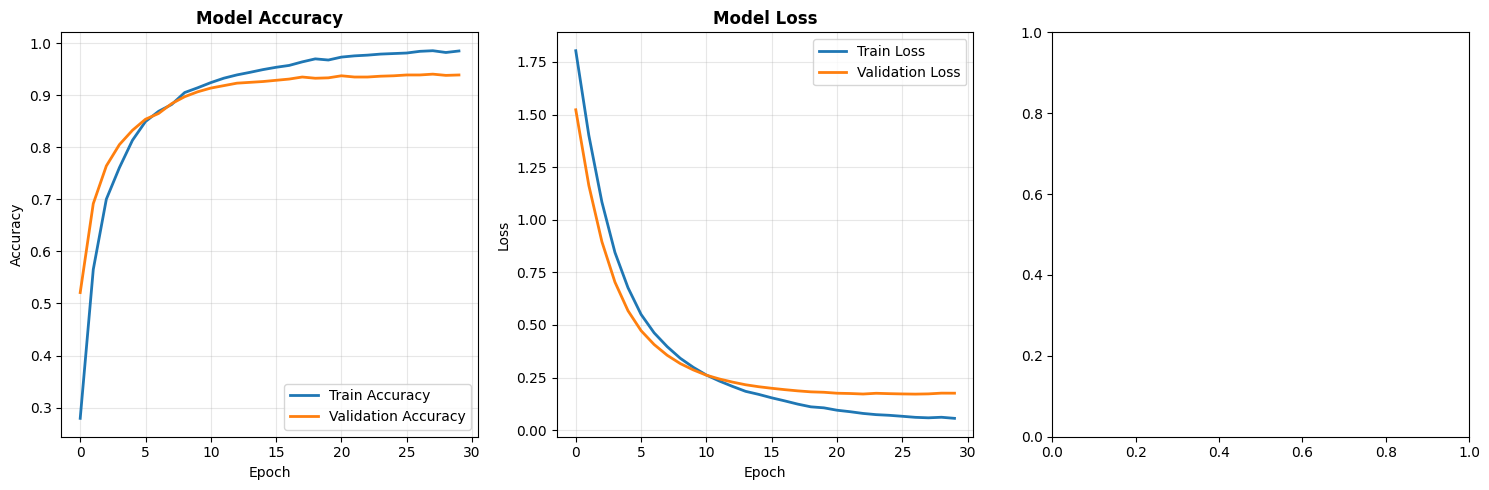

In [9]:
def train_model(model, train_ds, val_ds):
    """Train the model with callbacks"""
    print("=== TRAINING MODEL ===")

    # Setup callbacks
    checkpoint_cb = callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )

    earlystop_cb = callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_accuracy',
        verbose=1
    )

    reduce_lr_cb = callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )

    # Train model
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
        verbose=1
    )

    return history

def plot_training_history(history):
    """
    Visualize training history with comprehensive plots.

    Args:
        history: Training history from model.fit()
    """
    plt.figure(figsize=(15, 5))

    # Accuracy plot
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    plt.title('Model Accuracy', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss plot
    plt.subplot(1, 3, 2)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Model Loss', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Learning rate plot
    plt.subplot(1, 3, 3)
    if 'lr' in history.history:
        plt.plot(history.history['lr'], linewidth=2, color='red')
        plt.title('Learning Rate', fontweight='bold')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Train the model
history = train_model(model, train_ds, val_ds)
plot_training_history(history)

## **7. Model Evaluation and Performance Analysis**
Comprehensive evaluation of the trained model with detailed metrics and visualizations.

=== MODEL EVALUATION ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.9399
📉 Test Loss: 0.1714

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.84      0.85      0.84       163
             Caries       0.96      0.94      0.95       192
         Gingivitis       0.83      0.81      0.82       160
            Healthy       0.99      0.99      0.99       185
         Hypodontia       0.97      0.99      0.98       164
Tooth_discoloration       0.96      0.97      0.97       184
             Ulcers       1.00      0.99      1.00       200

           accuracy                           0.94      1248
          macro avg       0.94      0.94      0.94      1248
       weighted avg       0.94      0.94      0.94      1248



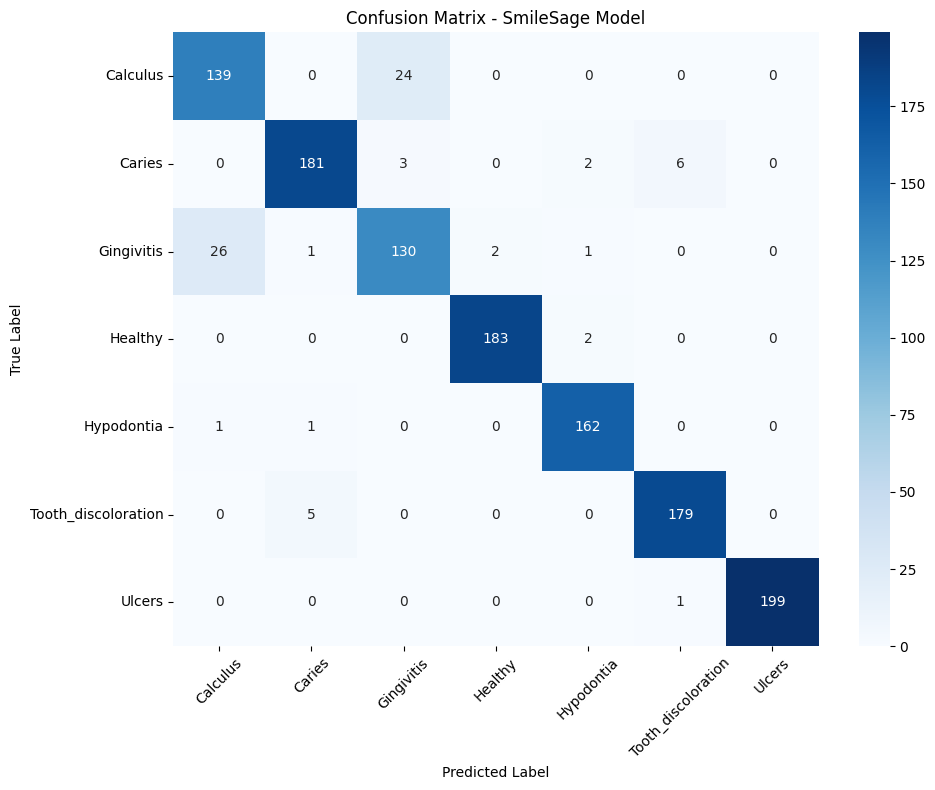

In [10]:
def evaluate_model(model, test_ds):
    """Comprehensive model evaluation"""
    print("=== MODEL EVALUATION ===")

    # Load best model
    if os.path.exists(MODEL_SAVE_PATH):
        model = models.load_model(MODEL_SAVE_PATH)
        print("✅ Loaded best saved model")

    # Evaluate on test set
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"🎯 Test Accuracy: {test_acc:.4f}")
    print(f"📉 Test Loss: {test_loss:.4f}")

    # Get predictions
    y_true = np.concatenate([y for x, y in test_ds])
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Classification report
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
    print("\n📊 Classification Report:")
    print(report)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - SmileSage Model')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return model, y_true, y_pred, y_pred_probs

# Evaluate model
model, y_true, y_pred, y_pred_probs = evaluate_model(model, test_ds)

## **8. Model Interpretability with Grad-CAM**
Implement Gradient-weighted Class Activation Mapping (Grad-CAM) to visualize what the model focuses on when making predictions.

In [11]:
# Inspect all layers inside EfficientNetB0
efficientnet = model.get_layer("efficientnetb0")

for layer in efficientnet.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print("✅ Last Conv2D layer name:", layer.name)
        break


✅ Last Conv2D layer name: top_conv


In [12]:
# Display model input information
print("🔎 Model input type:", type(model.input))
print("🔎 Model input shape:", model.input.shape)
print("🔎 Model input name:", model.input.name)


🔎 Model input type: <class 'keras.src.backend.common.keras_tensor.KerasTensor'>
🔎 Model input shape: (None, 224, 224, 3)
🔎 Model input name: input_layer


In [13]:
def get_img_array(img_path, size):
    """Load image and convert to array with preprocessing"""
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return preprocess_input(array)

def make_gradcam_heatmap(img_array, model, conv_layer_name="top_conv", pred_index=None):
    """
    Final working Grad-CAM fix using direct EfficientNetB0 base and manual forward pass.
    """
    # Step 1: Get EfficientNetB0 base
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )

    # Step 2: Get the conv layer
    conv_layer = base_model.get_layer(conv_layer_name)

    # Step 3: Build custom Grad-CAM model
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[conv_layer.output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array)
        x = tf.keras.layers.GlobalAveragePooling2D()(features)
        x = tf.keras.layers.Dropout(0.3)(x)
        predictions = tf.keras.layers.Dense(7, activation="softmax")(x)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_output = predictions[:, pred_index]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    """Overlay heatmap on image and display"""
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)

    # Save and show
    cv2.imwrite(cam_path, overlay)
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Overlay")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


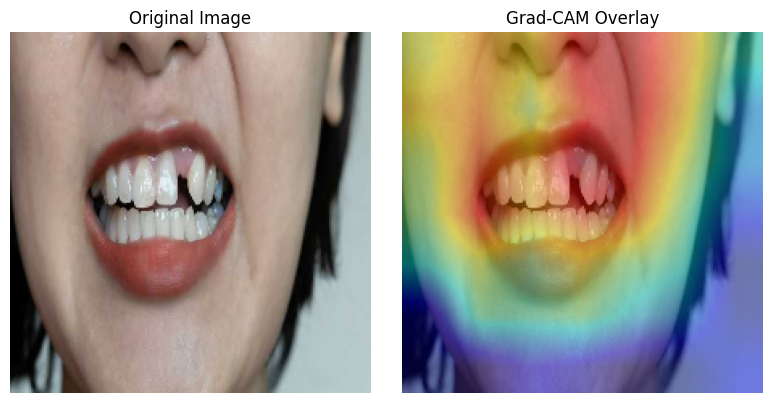

In [14]:
# TEST GRAD-CAM ON SAMPLE IMAGE

# Sample image path from dataset
sample_class = "Hypodontia"
sample_path = os.path.join(DATASET_PATH, sample_class, os.listdir(os.path.join(DATASET_PATH, sample_class))[1])

# Prepare input and generate Grad-CAM
img_array = tf.convert_to_tensor(get_img_array(sample_path, size=IMG_SIZE), dtype=tf.float32)
heatmap = make_gradcam_heatmap(img_array, model=None)

# Display results
display_gradcam(sample_path, heatmap)
